# Plot Rupture

In [1]:
# Import modules
import matplotlib.pyplot as plt
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon
import numpy as np

In [6]:
# Load in files

# Change the number of the rupture you want to visualize here
# You may need to adjust the addresses/filenames below, too
num = 2216

# Rupture file
No,lon,lat,z,strike,dip,rise,dura,ss_slip,ds_slip,ss_len,ds_len,rupt_time,rigidity,velocity = np.loadtxt(f"2_synthetic_data/ruptures/nankai.00{num}.rupt", unpack = True)

# Input file
lon, lat, z, slip_in = np.loadtxt(f"3_data_processing/Input0904/input-{num+2500}.csv", delimiter=",", skiprows = 1, unpack = True)

# Fault file
No, Lon, Lat, Z, N1Lon, N1Lat, N1Z, N2Lon, N2Lat, N2Z, N3Lon, N3Lat, N3Z, length, area, strike, dip = np.loadtxt("1_source_geometry/nankai.mshout", unpack=True)

# Calculate total slip
slip_rupt = np.sqrt(ss_slip**2+ds_slip**2)

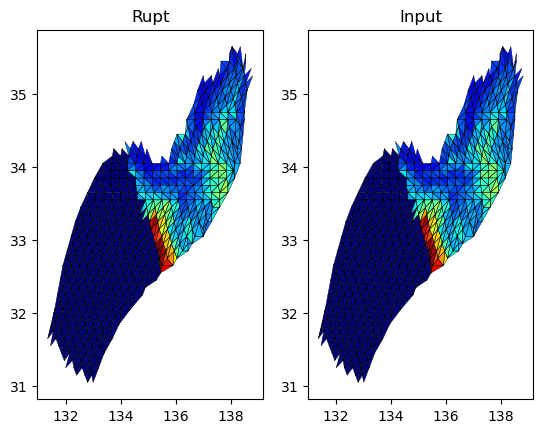

In [7]:
# Initialize plot
fig,ax = plt.subplots(1,2)

patches = []

for i in range(len(No)):
    # Determine polygons for subfaults
    verts = np.array([[N1Lon[i], N1Lat[i]],[N2Lon[i],N2Lat[i]],[N3Lon[i],N3Lat[i]]]) # random triangles, plus i to offset them
    polygon = Polygon(verts,closed=True)
    patches.append(polygon)

    # Plot black outline
    outlinex = np.array([N1Lon[i],N2Lon[i],N3Lon[i],N1Lon[i]])
    outliney = np.array([N1Lat[i],N2Lat[i],N3Lat[i],N1Lat[i]])
    ax[0].plot(outlinex, outliney, "-k",lw = 0.3)
    ax[1].plot(outlinex, outliney, "-k",lw = 0.3)

# Plot polygons
collection = PatchCollection(patches, cmap='jet')
collection.set_array(np.asarray(slip_rupt))
ax[0].add_collection(collection)
ax[0].set_title("Rupt")


# Plot polygons
collection = PatchCollection(patches, cmap='jet')
collection.set_array(np.asarray(slip_in[987:]))
ax[1].add_collection(collection)
ax[1].set_title("Input")

# Add colorbar
# plt.colorbar(collection, label = "Slip [m]")

plt.show()

# Plot Output

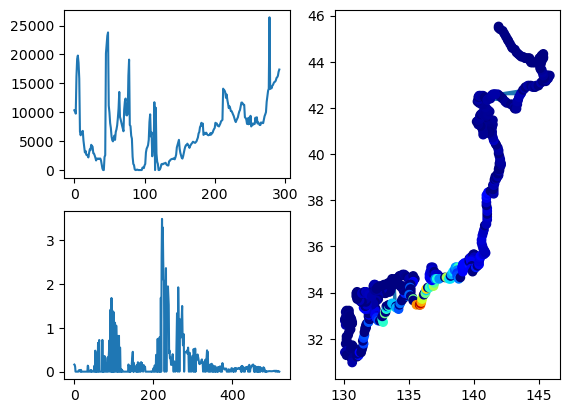

In [8]:
lon, lat, time, height, tin, hin = np.loadtxt(f"3_data_processing/Output0904/output-{num+2500}.csv", delimiter=",", skiprows=1, unpack=True)

plt.subplot(2,2,1)
plt.plot(time[tin.astype(bool)])

plt.subplot(2,2,3)
plt.plot(height[hin.astype(bool)])

plt.subplot(1,2,2)
plt.plot(lon, lat, zorder=-10)
plt.scatter(lon[hin.astype(bool)], lat[hin.astype(bool)], c=height[hin.astype(bool)], cmap='jet')